In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [41]:
df=pd.read_csv(r'C:\Users\dell\Downloads\Clean_data - Form responses 1.csv')
# remove leading/trailing spaces
df.columns = df.columns.str.strip()
df=df.drop(columns=['Score'])

In [42]:
# Remove respondents who did not prepare for JEE/NEET
df = df[df['Did you prepare for JEE/NEET'] == 'Yes'].reset_index(drop=True)
print(f"Cleaned dataset: {len(df)} responses")

Cleaned dataset: 335 responses


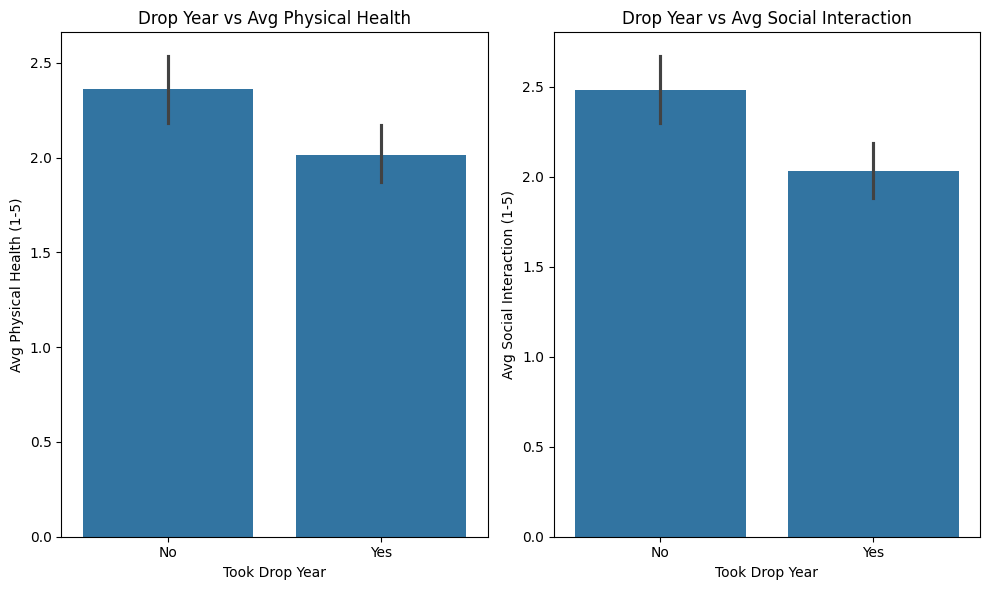

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Physical Health
sns.barplot(
    x='Did you take a drop year exclusively for JEE/NEET preparation?',
    y='Physical health during preparation',
    data=df,
    ax=axes[0]
)
axes[0].set_title('Drop Year vs Avg Physical Health')
axes[0].set_xlabel('Took Drop Year')
axes[0].set_ylabel('Avg Physical Health (1-5)')

# Social Interaction
sns.barplot(
    x='Did you take a drop year exclusively for JEE/NEET preparation?',
    y='Social interaction level',
    data=df,
    ax=axes[1]
)
axes[1].set_title('Drop Year vs Avg Social Interaction')
axes[1].set_xlabel('Took Drop Year')
axes[1].set_ylabel('Avg Social Interaction (1-5)')

plt.tight_layout()

plt.show()

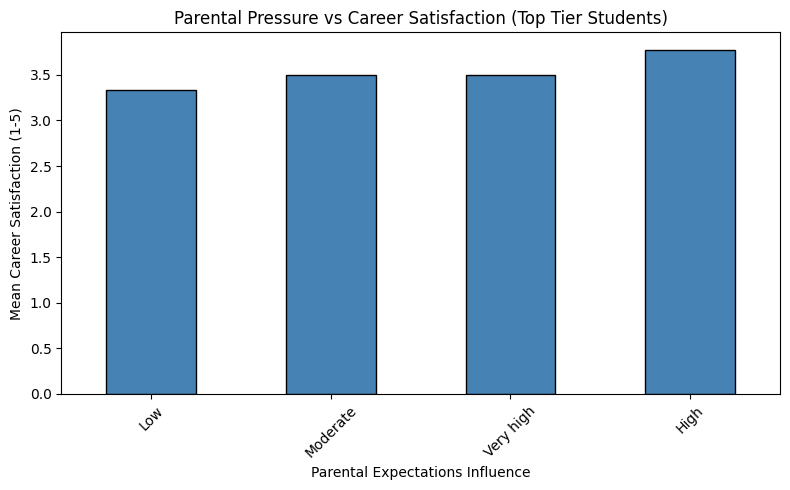

In [6]:
# Filter top tier students
top_tier = df[df['What was your JEE/NEET outcome?'] == 'Top tier (IIT / AIIMS)']

# Group by parental pressure and calculate mean satisfaction
pressure_satisfaction = top_tier.groupby('How much did parental expectations influence your preparation intensity?')['Rate your current satisfaction (education/career)'].mean().sort_values()

# Bar plot
plt.figure(figsize=(8,5))
pressure_satisfaction.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Parental Expectations Influence')
plt.ylabel('Mean Career Satisfaction (1-5)')
plt.title('Parental Pressure vs Career Satisfaction (Top Tier Students)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

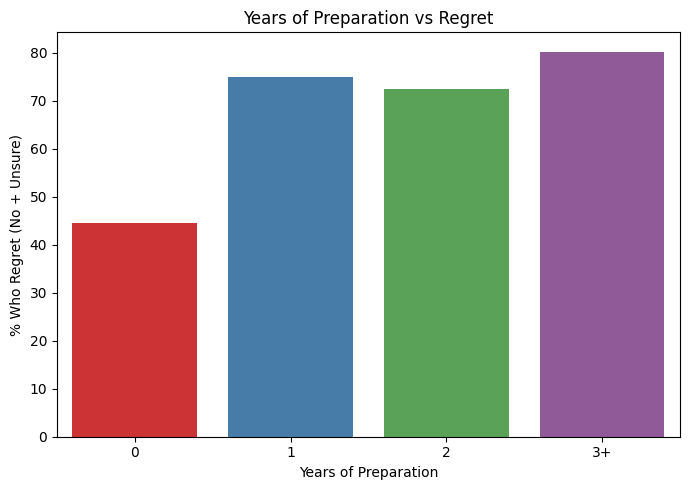

In [7]:

# regret = 1 if NOT 'Yes' (i.e., No + Unsure)
df['regret'] = df['Looking back, would you choose the same preparation path again?'] != 'Yes'

# group + %
regret_pct = df.groupby('Years of preparation')['regret'].mean() * 100

# plot
plt.figure(figsize=(7, 5))
sns.barplot(x=regret_pct.index, y=regret_pct.values, order=['0','1','2','3+'], palette='Set1')
plt.title('Years of Preparation vs Regret')
plt.xlabel('Years of Preparation')
plt.ylabel('% Who Regret (No + Unsure)')
plt.tight_layout()

plt.show()

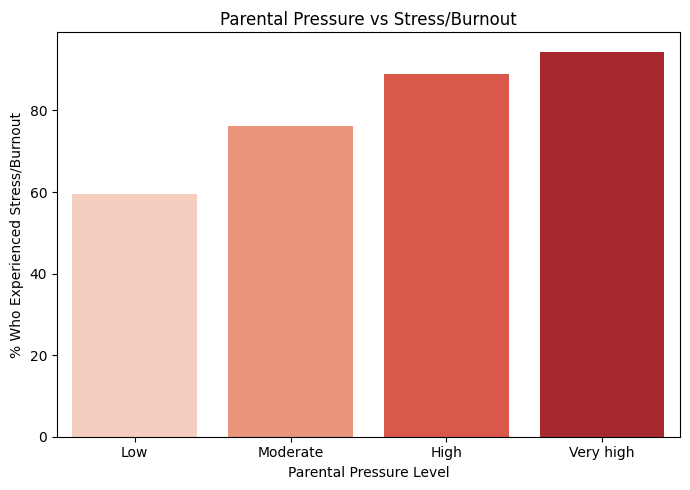

In [8]:
# creating a binary column: 1 if stressed, 0 if not
# we do this because stress_burnout is "Yes/No/Unsure" text — can't do math on text
df['stress_bin'] = (df['Did you experience frequent stress or burnout?'] == 'Yes').astype(int)

# groupby groups all rows with same pressure level together
# .mean() on 0/1 column gives proportion, *100 converts to percentage
stress_pct = df.groupby('How much did parental expectations influence your preparation intensity?')['stress_bin'].mean() * 100

# defining order manually because otherwise seaborn plots alphabetically (High, Low, Moderate, Very high) which makes no sense
order = ['Low', 'Moderate', 'High', 'Very high']

plt.figure(figsize=(7, 5))

# x is pressure level, y is the % stressed, order forces correct sequence
sns.barplot(x=stress_pct.index, y=stress_pct.values, order=order, palette='Reds')

plt.title('Parental Pressure vs Stress/Burnout')
plt.xlabel('Parental Pressure Level')
plt.ylabel('% Who Experienced Stress/Burnout')
plt.tight_layout()

plt.show()

In [9]:
df.columns

Index(['Did you prepare for JEE/NEET', 'Years of preparation',
       'What is your age group?',
       'Did you take a drop year exclusively for JEE/NEET preparation?',
       'What was your JEE/NEET outcome?', 'Type of schooling',
       'Daily study hours (peak)', 'Social interaction level',
       'Physical health during preparation',
       'Did you experience frequent stress or burnout?',
       'How much did parental expectations influence your preparation intensity?',
       'Rate your current satisfaction (education/career)',
       'Rate your current social confidence compared to others of your age',
       'Looking back, would you choose the same preparation path again?',
       'Would you recommend this path to others?',
       'Did you develop any non-academic skills during preparation', 'regret',
       'stress_bin'],
      dtype='object')

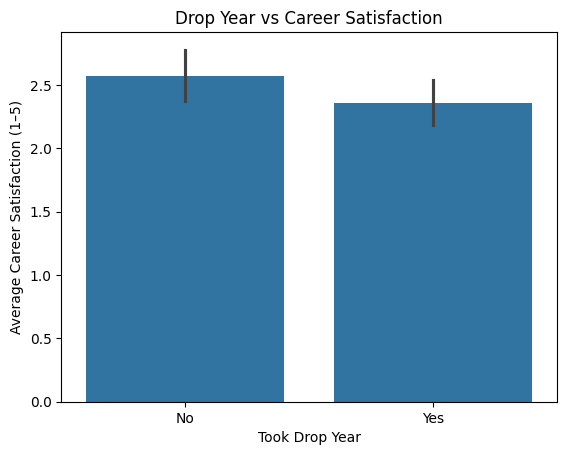

In [10]:

sns.barplot(
    x='Did you take a drop year exclusively for JEE/NEET preparation?',
    y='Rate your current satisfaction (education/career)',
    data=df
)

plt.title('Drop Year vs Career Satisfaction')
plt.xlabel('Took Drop Year')
plt.ylabel('Average Career Satisfaction (1–5)')
plt.show()

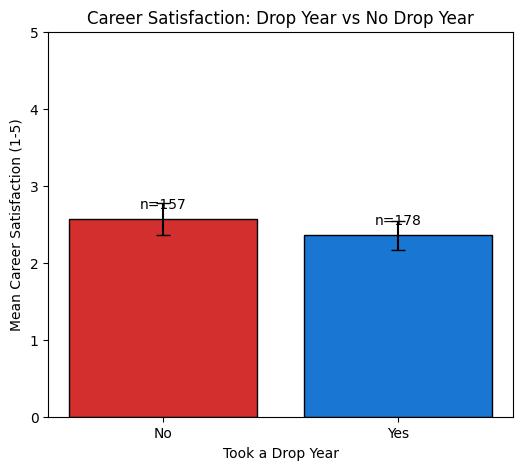

In [11]:
drop_satisfaction = df.groupby('Did you take a drop year exclusively for JEE/NEET preparation?')['Rate your current satisfaction (education/career)'].agg(['mean', 'sem', 'count']).reset_index()
drop_satisfaction.columns = ['Drop Year', 'Mean Satisfaction', 'SE', 'n']
drop_satisfaction['CI'] = drop_satisfaction['SE'] * 1.96  # 95% confidence interval

# Plot
plt.figure(figsize=(6,5))
bars = plt.bar(drop_satisfaction['Drop Year'], drop_satisfaction['Mean Satisfaction'], 
               yerr=drop_satisfaction['CI'], capsize=5, 
               color=['#d32f2f', '#1976d2'], edgecolor='black')
plt.ylabel('Mean Career Satisfaction (1-5)')
plt.xlabel('Took a Drop Year')
plt.title('Career Satisfaction: Drop Year vs No Drop Year')
plt.ylim(0, 5)

# Add sample sizes
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'n={drop_satisfaction["n"].iloc[i]}', ha='center', va='bottom')

plt.show()

In [12]:
df['Years of preparation'] = pd.Categorical(
    df['Years of preparation'],
    categories=['0','1','2','3+'],
    ordered=True)



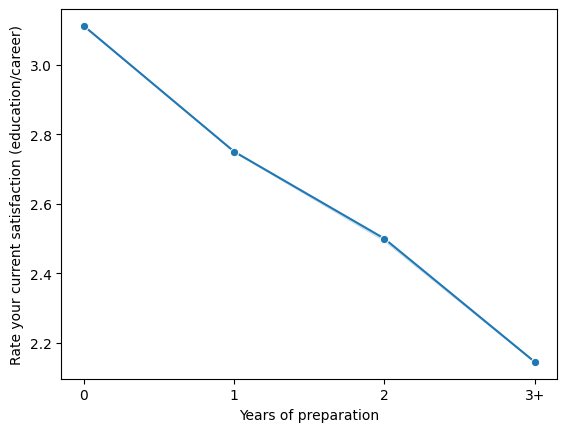

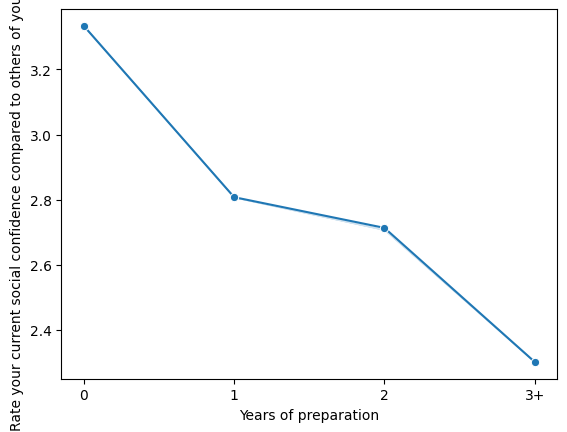

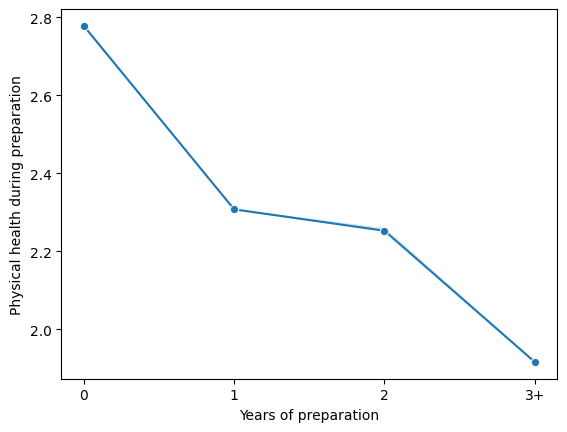

In [13]:
col=['Rate your current satisfaction (education/career)', 'Rate your current social confidence compared to others of your age',
     'Physical health during preparation']
for i in col:
    sns.lineplot(data=df, 
                 x='Years of preparation', 
                 y=i, marker='o', 
                 ci=0)
    plt.show()

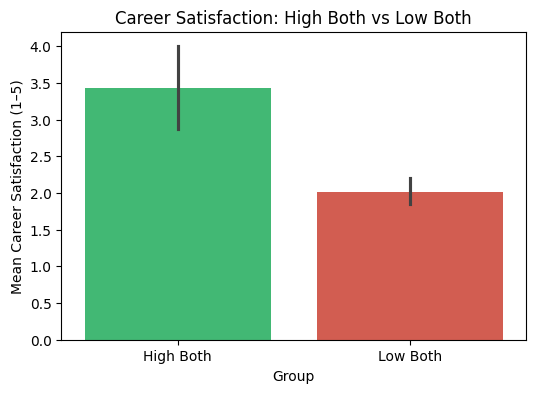

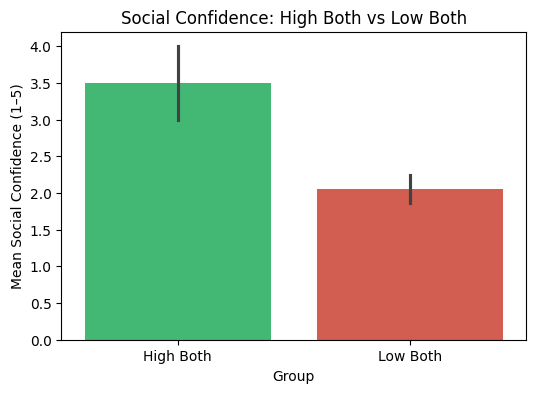

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define high/low thresholds
social_high = df['Social interaction level'] >= 4
social_low = df['Social interaction level'] <= 2
health_high = df['Physical health during preparation'] >= 4
health_low = df['Physical health during preparation'] <= 2

# Create groups
df['health_social_group'] = 'Mixed / Moderate'
df.loc[social_high & health_high, 'health_social_group'] = 'High Both'
df.loc[social_low & health_low, 'health_social_group'] = 'Low Both'

# Filter to extreme groups
grouped_df = df[df['health_social_group'].isin(['High Both', 'Low Both'])]

# Career satisfaction bar plot
plt.figure(figsize=(6,4))
sns.barplot(x='health_social_group', y='Rate your current satisfaction (education/career)', 
            data=grouped_df, order=['High Both', 'Low Both'], palette=['#2ecc71', '#e74c3c'])
plt.ylabel('Mean Career Satisfaction (1–5)')
plt.xlabel('Group')
plt.title('Career Satisfaction: High Both vs Low Both')
plt.show()

# Social confidence bar plot
plt.figure(figsize=(6,4))
sns.barplot(x='health_social_group', y='Rate your current social confidence compared to others of your age', 
            data=grouped_df, order=['High Both', 'Low Both'], palette=['#2ecc71', '#e74c3c'])
plt.ylabel('Mean Social Confidence (1–5)')
plt.xlabel('Group')
plt.title('Social Confidence: High Both vs Low Both')
plt.show()

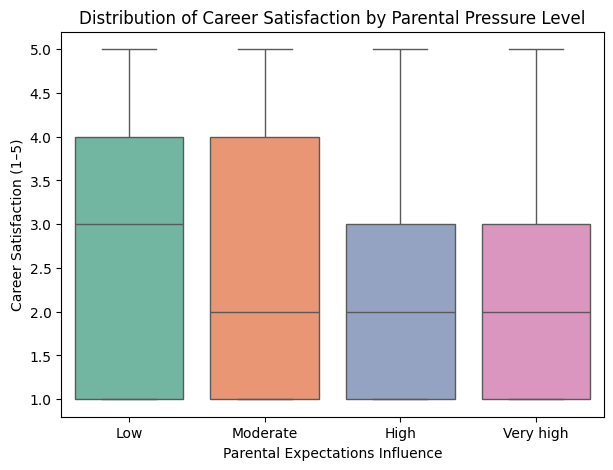

In [15]:
pressure_order = ['Low', 'Moderate', 'High', 'Very high']

plt.figure(figsize=(7,5))
sns.boxplot(x='How much did parental expectations influence your preparation intensity?',
            y='Rate your current satisfaction (education/career)',
            data=df, order=pressure_order, palette='Set2')
plt.ylabel('Career Satisfaction (1–5)')
plt.xlabel('Parental Expectations Influence')
plt.title('Distribution of Career Satisfaction by Parental Pressure Level')

plt.show()

In [16]:
df.columns

Index(['Did you prepare for JEE/NEET', 'Years of preparation',
       'What is your age group?',
       'Did you take a drop year exclusively for JEE/NEET preparation?',
       'What was your JEE/NEET outcome?', 'Type of schooling',
       'Daily study hours (peak)', 'Social interaction level',
       'Physical health during preparation',
       'Did you experience frequent stress or burnout?',
       'How much did parental expectations influence your preparation intensity?',
       'Rate your current satisfaction (education/career)',
       'Rate your current social confidence compared to others of your age',
       'Looking back, would you choose the same preparation path again?',
       'Would you recommend this path to others?',
       'Did you develop any non-academic skills during preparation', 'regret',
       'stress_bin', 'health_social_group'],
      dtype='object')

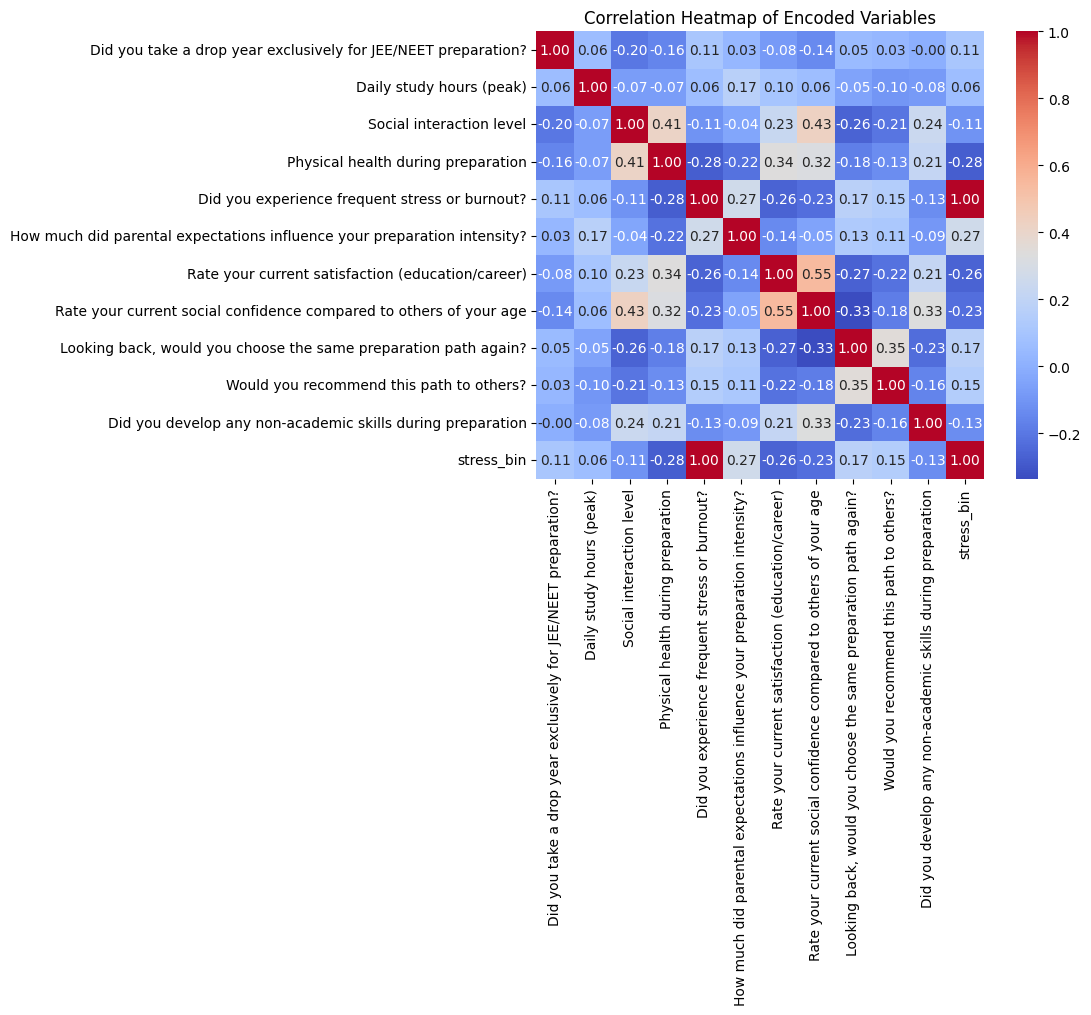

In [17]:
df_encoded = df.copy()

# Encode ordinal/nominal columns as specified
df_encoded['Years of preparation'] = df_encoded['Years of preparation'].map({'0':0, '1':1, '2':2, '3+':3})
df_encoded['Daily study hours (peak)'] = df_encoded['Daily study hours (peak)'].map({'0-4':1, '4-8':2, '8-12':3, '12+':4})
df_encoded['How much did parental expectations influence your preparation intensity?'] = df_encoded['How much did parental expectations influence your preparation intensity?'].map({'Low':1, 'Moderate':2, 'High':3, 'Very high':4})
df_encoded['Did you take a drop year exclusively for JEE/NEET preparation?'] = df_encoded['Did you take a drop year exclusively for JEE/NEET preparation?'].map({'No':0, 'Yes':1})
df_encoded['Did you experience frequent stress or burnout?'] = df_encoded['Did you experience frequent stress or burnout?'].map({'No':0, 'Unsure':0, 'Yes':1})  # treat Unsure as 0 or as separate? Here mapped to 0.
df_encoded['Looking back, would you choose the same preparation path again?'] = df_encoded['Looking back, would you choose the same preparation path again?'].map({'Yes':0, 'No':1, 'Unsure':1})
df_encoded['Would you recommend this path to others?'] = df_encoded['Would you recommend this path to others?'].map({'Yes':0, 'No':1, 'Unsure':1})
df_encoded['Did you develop any non-academic skills during preparation'] = df_encoded['Did you develop any non-academic skills during preparation'].map({'No':0, 'Yes':1})

# Select only numeric columns (all should be numeric after encoding)
numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
corr = df_encoded[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Encoded Variables')
plt.tight_layout()
plt.show()

In [18]:
# List of columns to check (adjust as needed)
cols_to_check = [
    'Did you prepare for JEE/NEET',
    'Did you take a drop year exclusively for JEE/NEET preparation?',
    'Did you experience frequent stress or burnout?',
    'Looking back, would you choose the same preparation path again?',
    'Would you recommend this path to others?',
    'Did you develop any non-academic skills during preparation'
]

# Loop and print value counts
for col in cols_to_check:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False))
    else:
        print(f"Column '{col}' not found in dataframe.")


--- Did you prepare for JEE/NEET ---
Did you prepare for JEE/NEET
Yes    335
Name: count, dtype: int64

--- Did you take a drop year exclusively for JEE/NEET preparation? ---
Did you take a drop year exclusively for JEE/NEET preparation?
Yes    178
No     157
Name: count, dtype: int64

--- Did you experience frequent stress or burnout? ---
Did you experience frequent stress or burnout?
Yes       269
No         34
Unsure     32
Name: count, dtype: int64

--- Looking back, would you choose the same preparation path again? ---
Looking back, would you choose the same preparation path again?
No        185
Yes        86
Unsure     64
Name: count, dtype: int64

--- Would you recommend this path to others? ---
Would you recommend this path to others?
No        209
Unsure     79
Yes        47
Name: count, dtype: int64

--- Did you develop any non-academic skills during preparation ---
Did you develop any non-academic skills during preparation
No     233
Yes    102
Name: count, dtype: int64


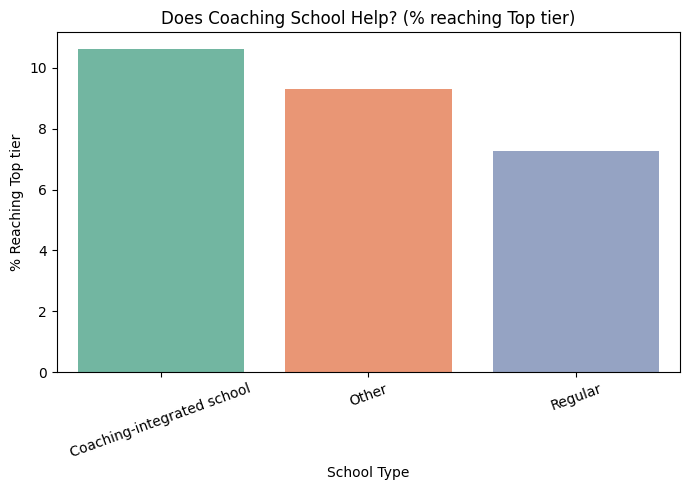

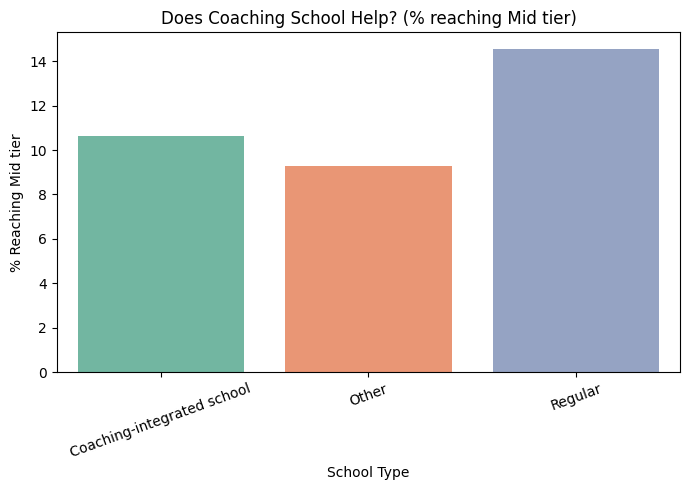

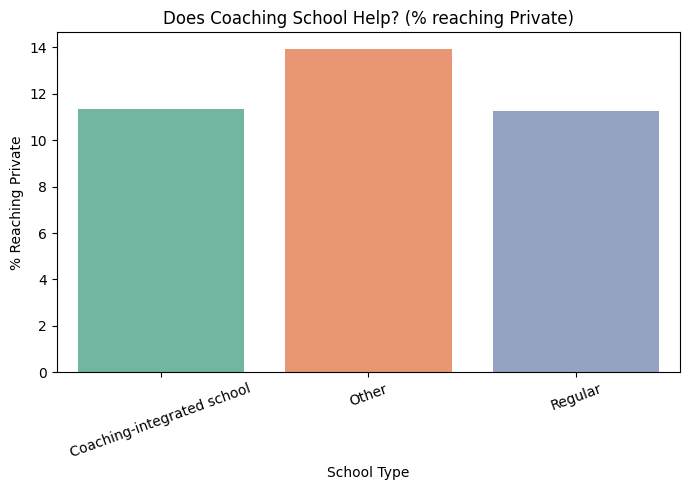

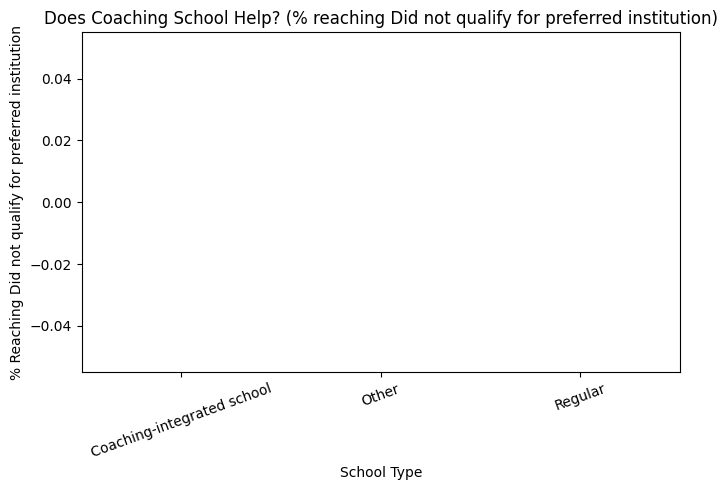

In [19]:
key = ['Top tier', 'Mid tier', 'Private', 'Did not qualify for preferred institution']

for x in key:
    df['tier'] = df['What was your JEE/NEET outcome?'].str.contains(x, na=False).astype(int)
    tier_pct = df.groupby('Type of schooling')['tier'].mean() * 100

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.barplot(x=tier_pct.index, y=tier_pct.values, palette='Set2', ax=ax)

    ax.set_title(f'Does Coaching School Help? (% reaching {x})')
    ax.set_xlabel('School Type')
    ax.set_ylabel(f'% Reaching {x}')
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

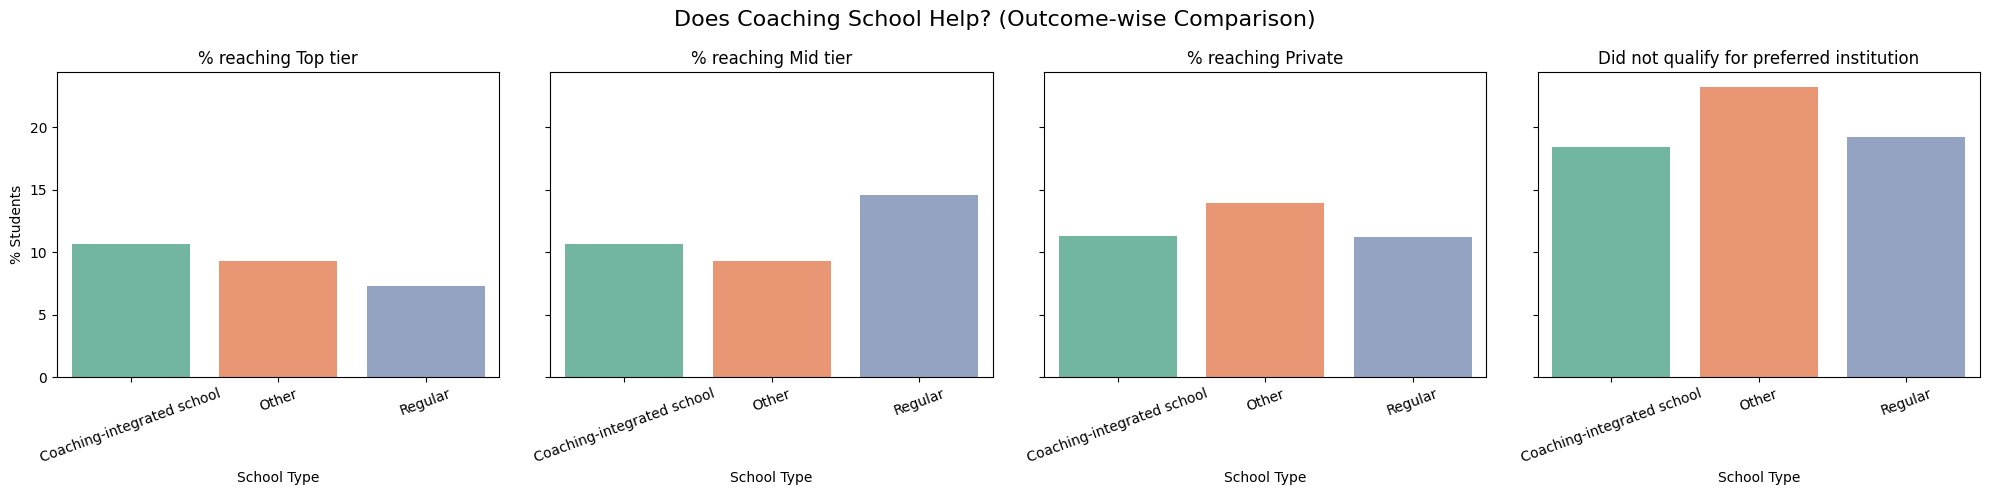

In [20]:
key = ['Top tier', 'Mid tier', 'Private', 'preferred']

fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, x in enumerate(key):

    # create binary column
    df['tier'] = (
        df['What was your JEE/NEET outcome?']
        .str.contains(x, na=False)
        .astype(int)
    )

    # percentage by school type
    tier_pct = (
        df.groupby('Type of schooling')['tier']
        .mean() * 100
    )

    # plot
    sns.barplot(
        x=tier_pct.index,
        y=tier_pct.values,
        palette='Set2',
        ax=axs[i]
    )

    # custom titles
    if x == 'preferred':
        axs[i].set_title('Did not qualify for preferred institution')
    else:
        axs[i].set_title(f'% reaching {x}')

    axs[i].set_xlabel('School Type')

    # only first subplot gets y-label
    if i == 0:
        axs[i].set_ylabel('% Students')
    else:
        axs[i].set_ylabel('')

    axs[i].tick_params(axis='x', rotation=20)

plt.suptitle(
    'Does Coaching School Help? (Outcome-wise Comparison)',
    fontsize=16
)

plt.tight_layout()


plt.show()

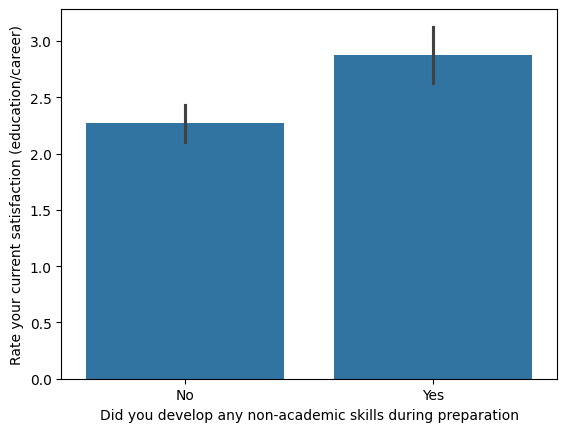

In [21]:
# Compare satisfaction
sns.barplot(x='Did you develop any non-academic skills during preparation', 
            y='Rate your current satisfaction (education/career)', data=df)

plt.show()

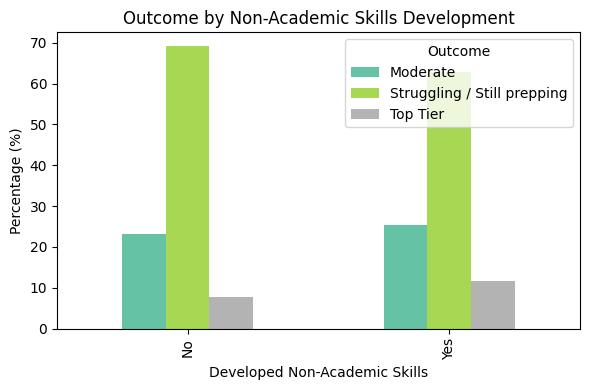

In [22]:
# Define outcome groups
def group_outcome(outcome):
    if 'Top tier' in str(outcome):
        return 'Top Tier'
    elif 'Mid tier' in str(outcome) or 'Private college' in str(outcome):
        return 'Moderate'
    else:
        return 'Struggling / Still prepping'

df['outcome_group'] = df['What was your JEE/NEET outcome?'].apply(group_outcome)

# Cross-tab with percentages
ct = pd.crosstab(df['Did you develop any non-academic skills during preparation'], 
                 df['outcome_group'], normalize='index') * 100

# Plot
ct.plot(kind='bar', stacked=False, figsize=(6,4), colormap='Set2')
plt.title('Outcome by Non-Academic Skills Development')
plt.ylabel('Percentage (%)')
plt.xlabel('Developed Non-Academic Skills')
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

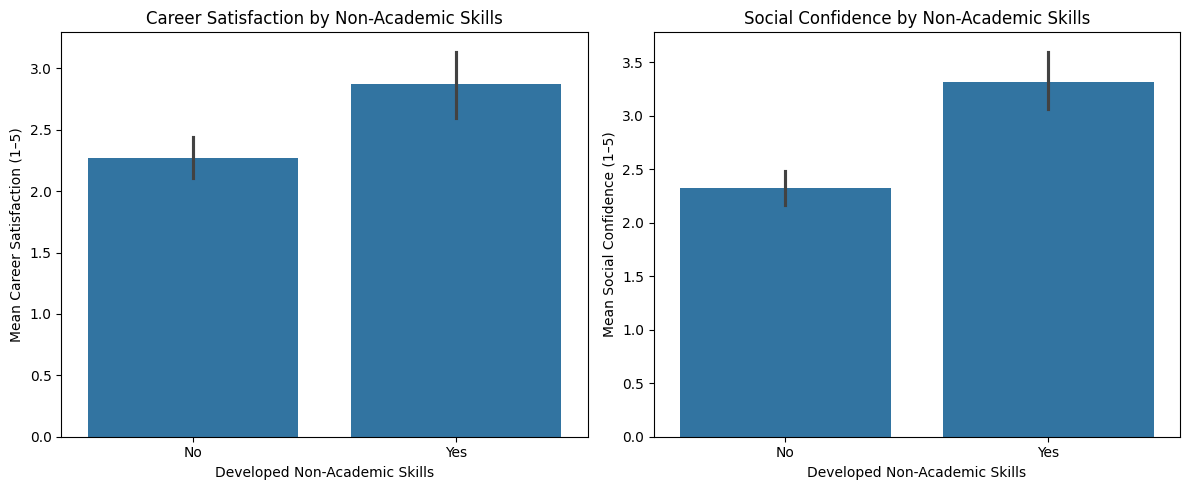

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First plot: Career Satisfaction
sns.barplot(x='Did you develop any non-academic skills during preparation', 
            y='Rate your current satisfaction (education/career)', 
            data=df, ci=95, ax=axes[0])
axes[0].set_title('Career Satisfaction by Non-Academic Skills')
axes[0].set_xlabel('Developed Non-Academic Skills')
axes[0].set_ylabel('Mean Career Satisfaction (1–5)')

# Second plot: Social Confidence
sns.barplot(x='Did you develop any non-academic skills during preparation', 
            y='Rate your current social confidence compared to others of your age', 
            data=df, ci=95, ax=axes[1])
axes[1].set_title('Social Confidence by Non-Academic Skills')
axes[1].set_xlabel('Developed Non-Academic Skills')
axes[1].set_ylabel('Mean Social Confidence (1–5)')

plt.tight_layout()

plt.show()

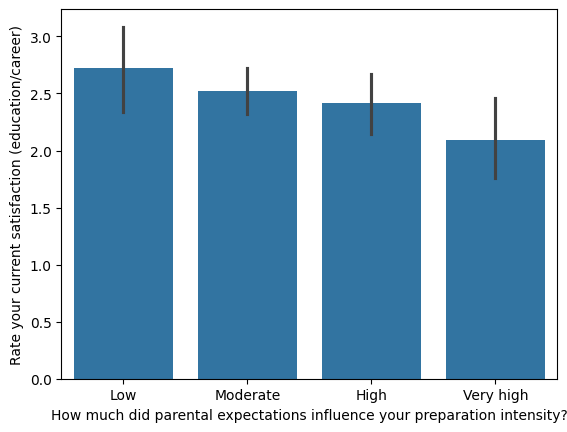

In [24]:
order = ['Low', 'Moderate', 'High', 'Very high']
sns.barplot(x='How much did parental expectations influence your preparation intensity?',
             y='Rate your current satisfaction (education/career)', data=df, ci=95, order=order)

plt.show()
#How much did parental expectations influence your preparation intensity?

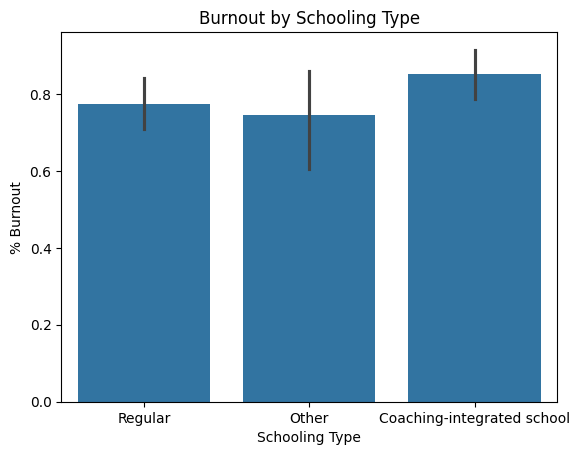

In [25]:
df['burnout'] = df['Did you experience frequent stress or burnout?'] == 'Yes'

sns.barplot(
    x='Type of schooling',
    y='burnout',
    data=df
)

plt.title('Burnout by Schooling Type')
plt.xlabel('Schooling Type')
plt.ylabel('% Burnout')

plt.show()

In [26]:
df.columns

Index(['Did you prepare for JEE/NEET', 'Years of preparation',
       'What is your age group?',
       'Did you take a drop year exclusively for JEE/NEET preparation?',
       'What was your JEE/NEET outcome?', 'Type of schooling',
       'Daily study hours (peak)', 'Social interaction level',
       'Physical health during preparation',
       'Did you experience frequent stress or burnout?',
       'How much did parental expectations influence your preparation intensity?',
       'Rate your current satisfaction (education/career)',
       'Rate your current social confidence compared to others of your age',
       'Looking back, would you choose the same preparation path again?',
       'Would you recommend this path to others?',
       'Did you develop any non-academic skills during preparation', 'regret',
       'stress_bin', 'health_social_group', 'tier', 'outcome_group',
       'burnout'],
      dtype='object')

In [27]:
df.groupby("How much did parental expectations influence your preparation intensity?")[
    "Rate your current satisfaction (education/career)"
].mean()

How much did parental expectations influence your preparation intensity?
High         2.417582
Low          2.723404
Moderate     2.524476
Very high    2.092593
Name: Rate your current satisfaction (education/career), dtype: float64

In [28]:
df["Did you experience frequent stress or burnout?"] = df[
    "Did you experience frequent stress or burnout?"
].map({"Yes": 1, "No": 0})

<Axes: xlabel='Daily study hours (peak)', ylabel='What was your JEE/NEET outcome?'>

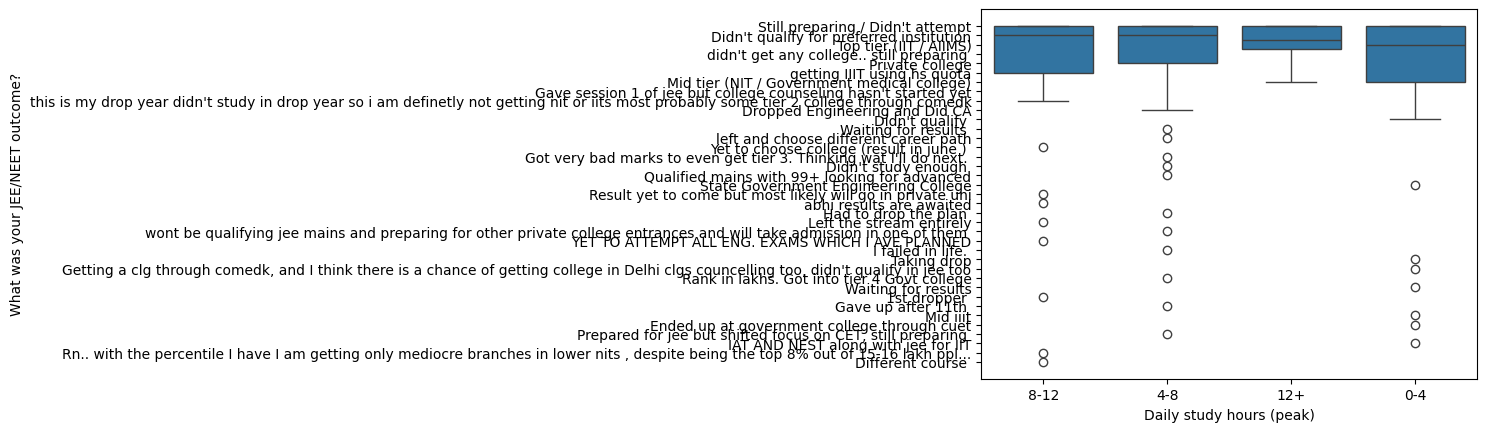

In [29]:
sns.boxplot(x="Daily study hours (peak)", y="What was your JEE/NEET outcome?", data=df)

In [30]:
df_young = df.query("`What is your age group?` == '16-18'")
df_mid = df.query("`What is your age group?` == '18-20'")

<Axes: xlabel='What is your age group?', ylabel='Rate your current satisfaction (education/career)'>

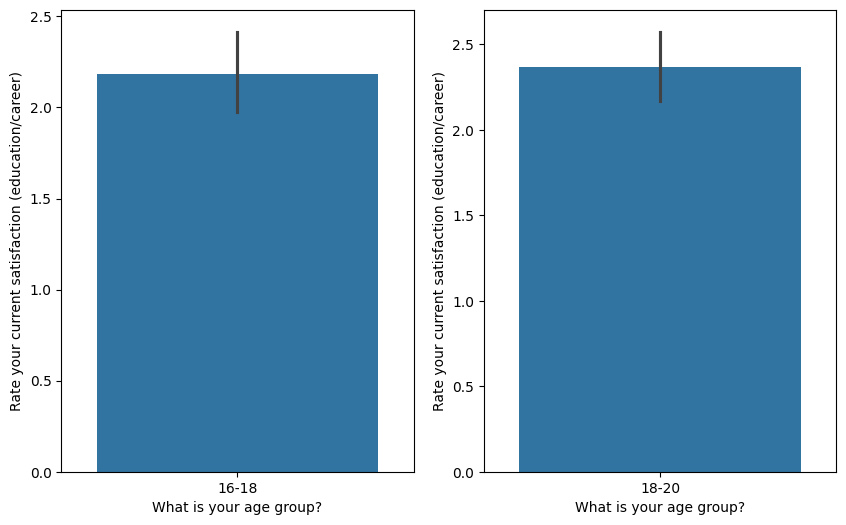

In [31]:
fig, axes=plt.subplots(1, 2, figsize=(10,6))
sns.barplot(x='What is your age group?', y='Rate your current satisfaction (education/career)',
            data=df_young, ax=axes[0])
sns.barplot(x='What is your age group?', y='Rate your current satisfaction (education/career)',
            data=df_mid, ax=axes[1])

In [32]:
print(df['How much did parental expectations influence your preparation intensity?'].unique())

['Moderate' 'High' 'Low' 'Very high']


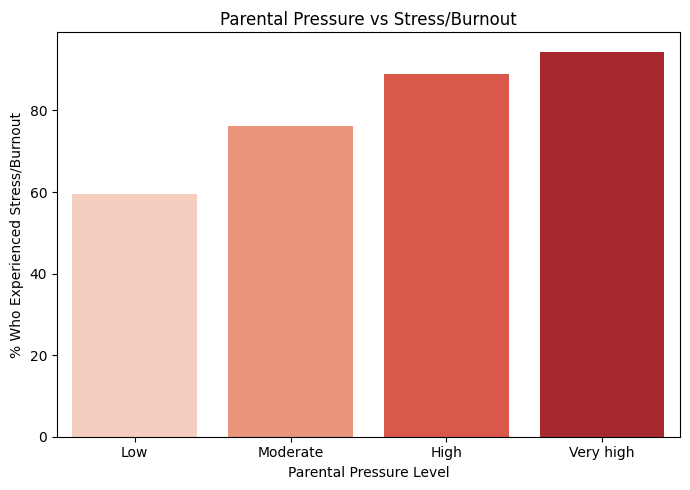

In [33]:
stress_pct = stress_pct.reindex(order)

plt.figure(figsize=(7,5))

sns.barplot(
    x=stress_pct.index,
    y=stress_pct.values,
    palette='Reds'
)

plt.title('Parental Pressure vs Stress/Burnout')
plt.xlabel('Parental Pressure Level')
plt.ylabel('% Who Experienced Stress/Burnout')

plt.tight_layout()


plt.show()

In [34]:
from scipy.stats import chi2_contingency

In [35]:
# 1. Age Group vs Burnout
age_burnout = df[df['Did you experience frequent stress or burnout?'].isin(['Yes','No'])].groupby(
    'What is your age group?')['Did you experience frequent stress or burnout?'].apply(
    lambda x: (x=='Yes').mean()*100).round(1)
print("Age Group vs Burnout %:")
print(age_burnout)
ct_age = pd.crosstab(df['What is your age group?'], df['Did you experience frequent stress or burnout?'])
chi, p, _, _ = chi2_contingency(ct_age)
print(f"Chi-square p={p:.4f}\n")

# 2. Drop Year vs Regret
drop_regret = df.groupby('Did you take a drop year exclusively for JEE/NEET preparation?')['Looking back, would you choose the same preparation path again?'].apply(
    lambda x: (x.isin(['No','Unsure'])).mean()*100).round(1)
print("Drop Year vs Regret %:")
print(drop_regret)
ct_drop = pd.crosstab(df['Did you take a drop year exclusively for JEE/NEET preparation?'], df['Looking back, would you choose the same preparation path again?'])
chi2, p2, _, _ = chi2_contingency(ct_drop)
print(f"Chi-square p={p2:.4f}\n")

# 3. Top Tier Outcome vs Would Not Recommend
top_tier = df[df['What was your JEE/NEET outcome?'].str.strip() == 'Top tier (IIT / AIIMS)']
no_recommend = (top_tier['Would you recommend this path to others?'].isin(['No','Unsure'])).mean()*100
print(f"IIT/AIIMS students who wouldn't recommend this path: {no_recommend:.1f}%")

Age Group vs Burnout %:
Series([], Name: Did you experience frequent stress or burnout?, dtype: float64)
Chi-square p=0.0919

Drop Year vs Regret %:
Did you take a drop year exclusively for JEE/NEET preparation?
No     72.0
Yes    76.4
Name: Looking back, would you choose the same preparation path again?, dtype: float64
Chi-square p=0.3363

IIT/AIIMS students who wouldn't recommend this path: 73.3%


In [36]:
raw_df = pd.read_csv(r'C:\Users\dell\Downloads\Clean_data - Form responses 1.csv')
comments = raw_df['(Optional) \nAnything else you want to share?'].dropna()
comments = comments[comments.str.strip() != '']
for i, comment in enumerate(comments, 1):
    print(f"[{i}] {comment.strip()}\n")

[1] a major part of why i got fucked over during my prep was coaching, i did put in a lotta effort but i was misguided by my teachers and me being the idiot i am, trusted them wholeheartedly and by the time i realised it was too late

[2] felt suicidal many times  , but parents ka soch ke nahi kiya .

[3] Destroyed my prescious years while I always wanted to persue career in cs it destroyed that dream too

[4] Fck NEET!!

[5] The single most important thing that I would say to anyone thinking of choosing these exams. Don't choose bio because you don't like maths or don't choose maths because bio is boring.

Experiment a little, do some research and then decide what you want to do, and which subjects will help you get there, then choose the subjects that will get you there.

[6] I am tired of this shit

[7] the exam and the journey takes away your happiness, potential, confidence, sleep, peace and gives you anxiety, panics, bad moods

[8] This journey hinders u from reaching ur true pot

In [37]:
raw_df.columns = raw_df.columns.str.strip()

In [38]:
# Verify IIT/AIIMS recommendation stats
top_tier = raw_df[raw_df['What was your JEE/NEET outcome?'].str.strip() == 'Top tier (IIT / AIIMS)']

print(f"Total IIT/AIIMS respondents: {len(top_tier)}\n")

print("=== WOULD YOU RECOMMEND THIS PATH? ===")
print(top_tier['Would you recommend this path to others?'].value_counts())

print("\n=== WOULD YOU CHOOSE SAME PATH AGAIN? ===")
print(top_tier['Looking back, would you choose the same preparation path again?'].value_counts())

print("\n=== INDIVIDUAL RESPONSES WITH COMMENTS ===")
cols = ['What was your JEE/NEET outcome?',
        'Would you recommend this path to others?',
        'Looking back, would you choose the same preparation path again?',
        '(Optional) \nAnything else you want to share?']
print(top_tier[cols].to_string())

Total IIT/AIIMS respondents: 30

=== WOULD YOU RECOMMEND THIS PATH? ===
Would you recommend this path to others?
No        13
Unsure     9
Yes        8
Name: count, dtype: int64

=== WOULD YOU CHOOSE SAME PATH AGAIN? ===
Looking back, would you choose the same preparation path again?
Yes       17
Unsure     7
No         6
Name: count, dtype: int64

=== INDIVIDUAL RESPONSES WITH COMMENTS ===
    What was your JEE/NEET outcome? Would you recommend this path to others? Looking back, would you choose the same preparation path again?                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [43]:
df.to_csv('Impact of JEE_NEET on students.csv', index=False)
print("Saved successfully")

Saved successfully


In [44]:
l=pd.read_csv('Impact of JEE_NEET on students.csv')
l

,Timestamp,Did you prepare for JEE/NEET,Years of preparation,What is your age group?,Did you take a drop year exclusively for JEE/NEET preparation?,What was your JEE/NEET outcome?,Type of schooling,Daily study hours (peak),Social interaction level,Physical health during preparation,Did you experience frequent stress or burnout?,How much did parental expectations influence your preparation intensity?,Rate your current satisfaction (education/career),Rate your current social confidence compared to others of your age,"Looking back, would you choose the same preparation path again?",Would you recommend this path to others?,Did you develop any non-academic skills during preparation,(Optional) \nAnything else you want to share?
0,28/03/2026 13:00:04,Yes,2,16-18,No,Still preparing / Didn't attempt,Regular,8-12,2,1,Yes,Moderate,1,1,No,Unsure,No,a major part of why i got fucked over during m...
1,28/03/2026 13:01:03,Yes,2,18-20,Yes,Still preparing / Didn't attempt,Regular,4-8,1,1,Yes,Moderate,2,1,Unsure,Unsure,No,"felt suicidal many times , but parents ka soc..."
2,28/03/2026 13:04:35,Yes,1,16-18,No,Still preparing / Didn't attempt,Other,8-12,3,4,Yes,High,3,4,Yes,Yes,Yes,NaN
3,28/03/2026 13:08:52,Yes,3+,18-20,Yes,Didn't qualify for preferred institution,Other,12+,1,1,Yes,Moderate,1,1,No,No,No,Destroyed my prescious years while I always wa...
4,28/03/2026 13:12:22,Yes,2,16-18,No,Still preparing / Didn't attempt,Regular,8-12,1,1,Yes,Moderate,2,1,No,No,Yes,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,30/04/2026 18:15:18,Yes,3+,18-20,Yes,Different course,Regular,8-12,2,2,Yes,High,2,2,No,Yes,No,Was a nightmare
331,01/05/2026 05:23:40,Yes,2,21-23,No,Private college,Regular,8-12,2,1,Unsure,Very high,3,5,No,No,Yes,Life can be shit but it's all about finding yo...
332,08/05/2026 19:55:49,Yes,3+,16-18,No,Still preparing / Didn't attempt,Regular,8-12,5,2,Yes,High,2,4,Yes,No,Yes,Ig the prep by itself is for ppl who liek the ...
333,09/05/2026 06:31:11,Yes,1,18-20,Yes,Didn't qualify for preferred institution,Regular,4-8,1,1,Yes,Very high,2,1,Unsure,Unsure,Yes,"its all about caliber & focus of individual,an..."
